#Preprocessing

#[1] Importing Libraries

In [ ]:
import pandas as pd
import ast
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import PowerTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm
import math
import pickle
from google.colab import files
uploaded = files.upload()

Saving parkinsons_disease_data_reg.csv to parkinsons_disease_data_reg.csv


#[2] Loading the dataset

In [ ]:
data=pd.read_csv('parkinsons_disease_data_reg.csv')

#**[3] Overview of the Dataset**

- First look at the dataset and the features.

In [ ]:
data.head(5)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,DietQuality,SleepQuality,...,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment,DoctorInCharge,WeeklyPhysicalActivity (hr),MedicalHistory,Symptoms
0,3530,64,Female,Caucasian,NaN,31.243092,No,6.157042,4.331705,6.291197,...,82.366509,25.542044,237.290807,4.161620,28.626480,5.355055,DrXXXConfid,04:14,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines..."
1,4848,79,Male,Asian,Higher,32.964518,No,5.192872,5.793078,8.603542,...,176.637077,23.098051,150.130321,176.220403,20.310768,9.927998,DrXXXConfid,00:59,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines..."
2,4289,85,Male,Other,NaN,16.092385,No,9.920555,5.442308,8.894049,...,198.444151,66.076197,66.871417,133.280607,20.614060,5.704308,DrXXXConfid,05:38,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'Yes', 'Rigidity': 'No', 'Bradykine..."
3,4751,84,Female,Caucasian,High School,39.145792,Yes,18.875195,8.407833,8.300877,...,134.669056,41.725854,248.163486,155.952027,4.237696,7.250435,DrXXXConfid,05:02,"{'FamilyHistoryParkinsons': 'Yes', 'TraumaticB...","{'Tremor': 'No', 'Rigidity': 'Yes', 'Bradykine..."
4,4242,59,Male,African American,NaN,15.987603,Yes,2.854129,5.797936,7.714292,...,59.598420,23.251949,127.747693,49.523001,21.475758,6.119130,DrXXXConfid,00:08,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines..."


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   PatientID                    2025 non-null   int64  
 1   Age                          2025 non-null   int64  
 2   Gender                       2025 non-null   object 
 3   Ethnicity                    2025 non-null   object 
 4   EducationLevel               1651 non-null   object 
 5   BMI                          2025 non-null   float64
 6   Smoking                      2025 non-null   object 
 7   AlcoholConsumption           2025 non-null   float64
 8   DietQuality                  2025 non-null   float64
 9   SleepQuality                 2025 non-null   float64
 10  SystolicBP                   2025 non-null   int64  
 11  DiastolicBP                  2025 non-null   int64  
 12  CholesterolTotal             2025 non-null   float64
 13  CholesterolLDL    

In [ ]:
data.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,374
BMI,0
Smoking,0
AlcoholConsumption,0
DietQuality,0
SleepQuality,0


In [ ]:
data.describe()

,PatientID,Age,BMI,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment
count,2025.00000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000
mean,4112.98716,69.652346,27.162397,10.063892,4.896189,7.002411,133.815309,90.197037,226.805594,126.179968,59.613945,222.814905,101.519190,15.027270,4.990583
std,608.71494,11.571040,7.222145,5.694348,2.874157,1.751285,26.586488,17.037746,43.717872,43.455005,23.464930,101.819477,56.513180,8.613916,2.935980
min,3058.00000,50.000000,15.008333,0.002228,0.000011,4.000497,90.000000,60.000000,150.062698,50.130454,20.027981,50.113604,0.028441,0.021191,0.001505
25%,3587.00000,60.000000,20.757513,5.160093,2.446423,5.501449,110.000000,75.000000,189.048799,88.815994,39.399494,132.520174,53.390605,7.469156,2.399154
50%,4112.00000,70.000000,27.119731,10.109640,4.788005,6.930472,133.000000,91.000000,228.464785,126.938405,59.182378,222.634972,102.715326,14.849281,4.976213
75%,4639.00000,80.000000,33.394469,14.858553,7.340610,8.560994,157.000000,105.000000,264.774192,164.103480,79.473546,311.541704,149.831682,22.530314,7.495758
max,5162.00000,89.000000,39.999887,19.988866,9.995864,9.999821,179.000000,119.000000,299.963074,199.985981,99.982265,399.975022,198.953604,29.970107,9.992697


#[4] Dropping Unimportant Columns

- PatientId was dropped because all the values are unique, and DoctorInCharge was dropped because all the values were the same.

In [ ]:
data.drop(columns=['PatientID', 'DoctorInCharge'], inplace=True)
data.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,...,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment,WeeklyPhysicalActivity (hr),MedicalHistory,Symptoms
0,64,Female,Caucasian,NaN,31.243092,No,6.157042,4.331705,6.291197,112,...,214.074273,82.366509,25.542044,237.290807,4.161620,28.626480,5.355055,04:14,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines..."
1,79,Male,Asian,Higher,32.964518,No,5.192872,5.793078,8.603542,124,...,271.105498,176.637077,23.098051,150.130321,176.220403,20.310768,9.927998,00:59,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines..."
2,85,Male,Other,NaN,16.092385,No,9.920555,5.442308,8.894049,97,...,279.608808,198.444151,66.076197,66.871417,133.280607,20.614060,5.704308,05:38,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'Yes', 'Rigidity': 'No', 'Bradykine..."
3,84,Female,Caucasian,High School,39.145792,Yes,18.875195,8.407833,8.300877,138,...,271.365480,134.669056,41.725854,248.163486,155.952027,4.237696,7.250435,05:02,"{'FamilyHistoryParkinsons': 'Yes', 'TraumaticB...","{'Tremor': 'No', 'Rigidity': 'Yes', 'Bradykine..."
4,59,Male,African American,NaN,15.987603,Yes,2.854129,5.797936,7.714292,169,...,293.662385,59.598420,23.251949,127.747693,49.523001,21.475758,6.119130,00:08,"{'FamilyHistoryParkinsons': 'No', 'TraumaticBr...","{'Tremor': 'No', 'Rigidity': 'No', 'Bradykines..."


In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,374
BMI,0
Smoking,0
AlcoholConsumption,0
DietQuality,0
SleepQuality,0
SystolicBP,0


In [ ]:
data.describe()

,Age,BMI,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,UPDRS,MoCA,FunctionalAssessment
count,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000
mean,69.652346,27.162397,10.063892,4.896189,7.002411,133.815309,90.197037,226.805594,126.179968,59.613945,222.814905,101.519190,15.027270,4.990583
std,11.571040,7.222145,5.694348,2.874157,1.751285,26.586488,17.037746,43.717872,43.455005,23.464930,101.819477,56.513180,8.613916,2.935980
min,50.000000,15.008333,0.002228,0.000011,4.000497,90.000000,60.000000,150.062698,50.130454,20.027981,50.113604,0.028441,0.021191,0.001505
25%,60.000000,20.757513,5.160093,2.446423,5.501449,110.000000,75.000000,189.048799,88.815994,39.399494,132.520174,53.390605,7.469156,2.399154
50%,70.000000,27.119731,10.109640,4.788005,6.930472,133.000000,91.000000,228.464785,126.938405,59.182378,222.634972,102.715326,14.849281,4.976213
75%,80.000000,33.394469,14.858553,7.340610,8.560994,157.000000,105.000000,264.774192,164.103480,79.473546,311.541704,149.831682,22.530314,7.495758
max,89.000000,39.999887,19.988866,9.995864,9.999821,179.000000,119.000000,299.963074,199.985981,99.982265,399.975022,198.953604,29.970107,9.992697


#[5] Filling missing values

- EducationLevel had null values so we substituted the null values for the mode which was "High School"


In [ ]:
mode_value = data['EducationLevel'].mode()[0]
data['EducationLevel'].fillna(mode_value, inplace=True)
print(data['EducationLevel'].mode()[0])

print(data.isnull().sum())

High School
Age                            0
Gender                         0
Ethnicity                      0
EducationLevel                 0
BMI                            0
Smoking                        0
AlcoholConsumption             0
DietQuality                    0
SleepQuality                   0
SystolicBP                     0
DiastolicBP                    0
CholesterolTotal               0
CholesterolLDL                 0
CholesterolHDL                 0
CholesterolTriglycerides       0
UPDRS                          0
MoCA                           0
FunctionalAssessment           0
WeeklyPhysicalActivity (hr)    0
MedicalHistory                 0
Symptoms                       0
dtype: int64


#[6] Encoding

## Converting stringified dictionary into columns and encoding them

In [ ]:
data['MedicalHistory'] = data['MedicalHistory'].apply(ast.literal_eval)
medical_history_data = pd.json_normalize(data['MedicalHistory'])
medical_history_data = medical_history_data.replace({'Yes': 1, 'No': 0})
data = pd.concat([data.drop(columns=['MedicalHistory']), medical_history_data], axis=1)

data['Symptoms'] = data['Symptoms'].apply(ast.literal_eval)
Symptoms_data = pd.json_normalize(data['Symptoms'])
Symptoms_data = Symptoms_data.replace({'Yes': 1, 'No': 0})
data = pd.concat([data.drop(columns=['Symptoms']), Symptoms_data], axis=1)

##Initializing encoders

In [ ]:
le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False)

## One-Hot Encode Ethnicity and Education Level
- One-Hot encoding was used because the order in this case is meaningless.

In [ ]:
ethnicity_encoded = ohe.fit_transform(data[['Ethnicity']])
ethnicity_df = pd.DataFrame(ethnicity_encoded, columns=ohe.get_feature_names_out(['Ethnicity']))
data = pd.concat([data.drop(columns=['Ethnicity']), ethnicity_df], axis=1)

education_encoded = ohe.fit_transform(data[['EducationLevel']])
education_df = pd.DataFrame(education_encoded, columns=ohe.get_feature_names_out(['EducationLevel']))
data = pd.concat([data.drop(columns=['EducationLevel']), education_df], axis=1)

##Encoding Gender and Smoking columns using label Encoding

- Label Encoding was used because the values were binary.

In [ ]:
cols_to_encode = ['Gender', 'Smoking']
for col in cols_to_encode:
    data[col] = le.fit_transform(data[col])

#[7] Converting the WeeklyPhysicalActivity from String to Minutes

In [ ]:
def convert_to_minutes(time_str):
    hours, minutes = map(int, time_str.split(':'))
    return hours * 60 + minutes

data['WeeklyPhysicalActivity (hr)'] = data['WeeklyPhysicalActivity (hr)'].apply(convert_to_minutes)

In [ ]:
data.describe()

,Age,Gender,BMI,Smoking,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,...,SpeechProblems,SleepDisorders,Constipation,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Other,EducationLevel_Bachelor's,EducationLevel_High School,EducationLevel_Higher
count,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,...,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000,2025.000000
mean,69.652346,0.508642,27.162397,0.294815,10.063892,4.896189,7.002411,133.815309,90.197037,226.805594,...,0.294815,0.244444,0.302222,0.200000,0.095309,0.603457,0.101235,0.312099,0.582222,0.105679
std,11.571040,0.500049,7.222145,0.456072,5.694348,2.874157,1.751285,26.586488,17.037746,43.717872,...,0.456072,0.429863,0.459334,0.400099,0.293713,0.489300,0.301714,0.463464,0.493315,0.307502
min,50.000000,0.000000,15.008333,0.000000,0.002228,0.000011,4.000497,90.000000,60.000000,150.062698,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,0.000000,20.757513,0.000000,5.160093,2.446423,5.501449,110.000000,75.000000,189.048799,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,70.000000,1.000000,27.119731,0.000000,10.109640,4.788005,6.930472,133.000000,91.000000,228.464785,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,80.000000,1.000000,33.394469,1.000000,14.858553,7.340610,8.560994,157.000000,105.000000,264.774192,...,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,89.000000,1.000000,39.999887,1.000000,19.988866,9.995864,9.999821,179.000000,119.000000,299.963074,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#[8] Exploratory Data Analysis

## Classify columns into categorical and numerical, then detect outliers in numerical columns using the IQR method.

- No outliers were detected

In [ ]:
categorical_cols = [
    'Gender', 'Smoking',
    'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension', 'Diabetes',
    'Depression', 'Stroke', 'Tremor', 'Rigidity', 'SleepDisorders', 'Bradykinesia', 'PosturalInstability',
    'SpeechProblems','Constipation','Ethnicity_African American', 'Ethnicity_Asian', 'Ethnicity_Caucasian',
    'Ethnicity_Other','EducationLevel_Bachelor\'s', 'EducationLevel_High School',
    'EducationLevel_Higher'
]

numerical_cols = [col for col in data.columns if col not in categorical_cols if col != 'UPDRS']
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(f"Outliers in '{col}':")
    print(outliers[[col]])
    print("-" * 40)

Outliers in 'Age':
Empty DataFrame
Columns: [Age]
Index: []
----------------------------------------
Outliers in 'BMI':
Empty DataFrame
Columns: [BMI]
Index: []
----------------------------------------
Outliers in 'AlcoholConsumption':
Empty DataFrame
Columns: [AlcoholConsumption]
Index: []
----------------------------------------
Outliers in 'DietQuality':
Empty DataFrame
Columns: [DietQuality]
Index: []
----------------------------------------
Outliers in 'SleepQuality':
Empty DataFrame
Columns: [SleepQuality]
Index: []
----------------------------------------
Outliers in 'SystolicBP':
Empty DataFrame
Columns: [SystolicBP]
Index: []
----------------------------------------
Outliers in 'DiastolicBP':
Empty DataFrame
Columns: [DiastolicBP]
Index: []
----------------------------------------
Outliers in 'CholesterolTotal':
Empty DataFrame
Columns: [CholesterolTotal]
Index: []
----------------------------------------
Outliers in 'CholesterolLDL':
Empty DataFrame
Columns: [CholesterolLDL]


## Plot all columns: use count plots for categorical features and box plots for numerical features.

- No outliers were detected in the data.
- No skewness was detected in the data.

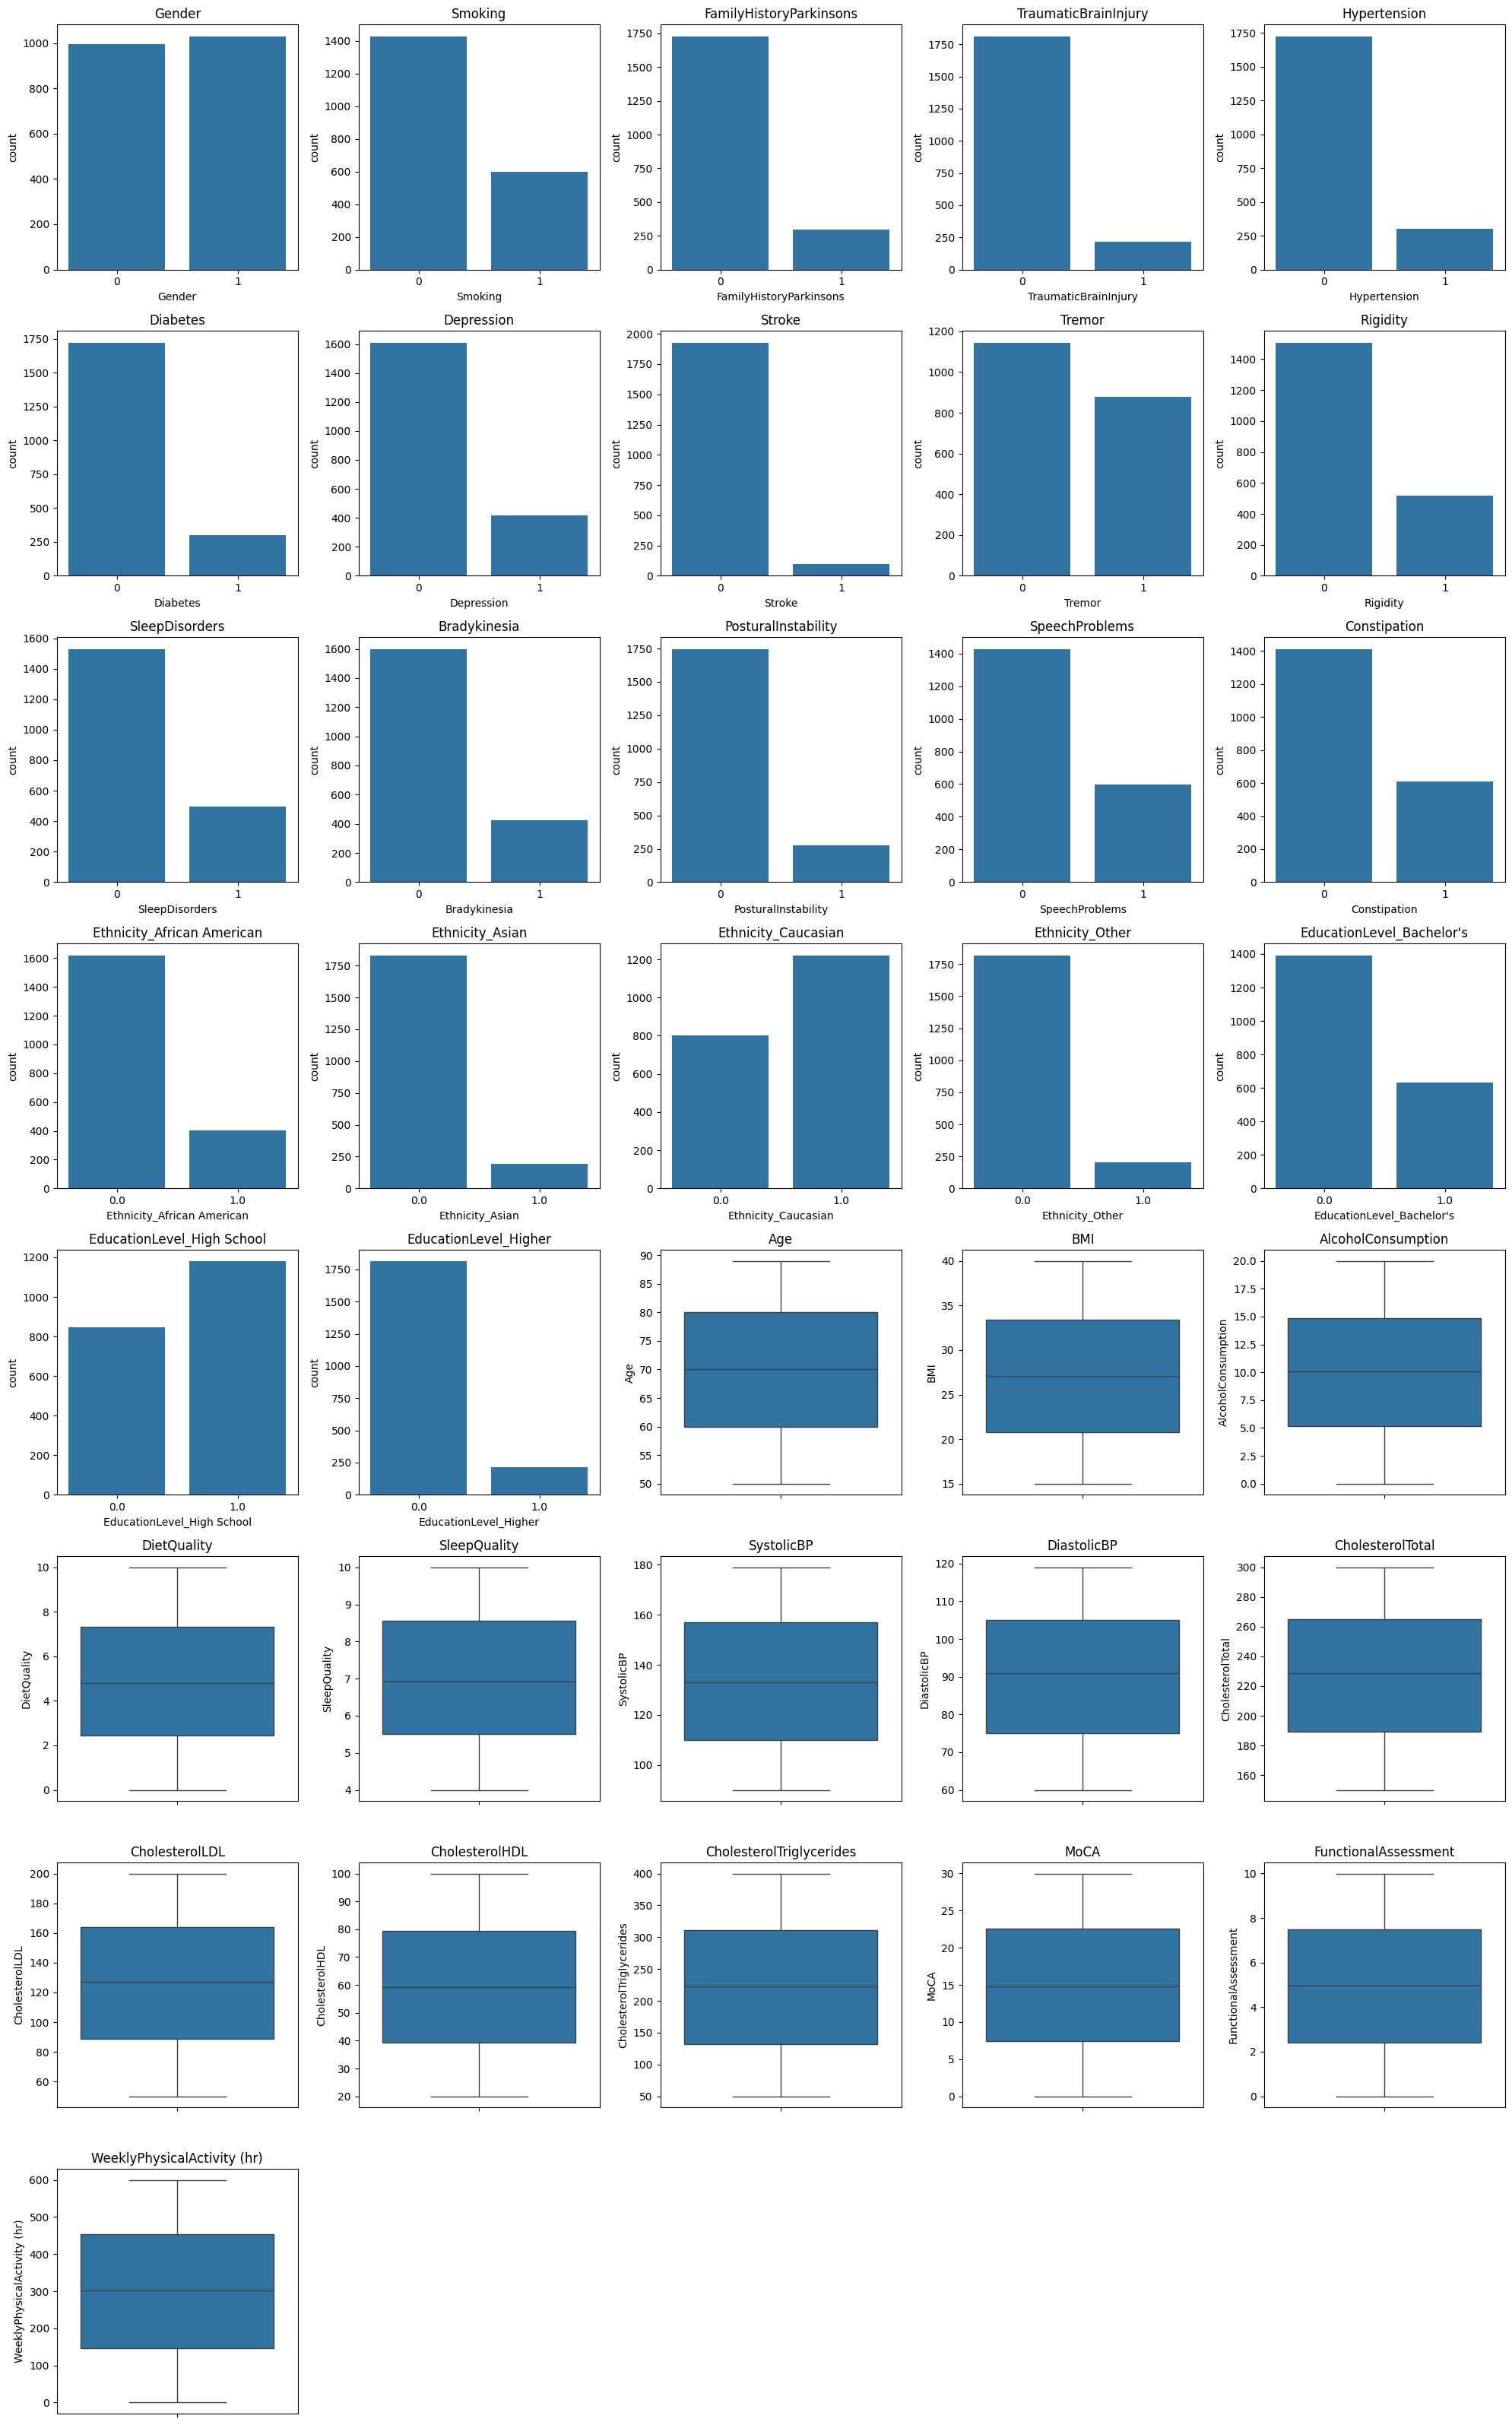

In [ ]:
all_cols = categorical_cols + numerical_cols
cols = 5
rows = math.ceil(len(all_cols) / cols)
fig, ax = plt.subplots(ncols=cols, nrows=rows, figsize=(cols * 4, rows * 4))
ax = ax.flatten()
for i, col in enumerate(all_cols):
    if col in categorical_cols:
        sns.countplot(x=col, data=data, ax=ax[i])
    else:
        sns.boxplot(y=col, data=data, ax=ax[i])
    ax[i].set_title(col)
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()


##Checking the sckewness of the data

- No skewness was detected in the data.

In [ ]:
print(data[numerical_cols].skew())

Age                           -0.040099
BMI                            0.043673
AlcoholConsumption            -0.025000
DietQuality                    0.044134
SleepQuality                   0.003787
SystolicBP                     0.023093
DiastolicBP                   -0.057249
CholesterolTotal              -0.052316
CholesterolLDL                -0.022570
CholesterolHDL                 0.006291
CholesterolTriglycerides       0.021174
MoCA                          -0.011829
FunctionalAssessment           0.014744
WeeklyPhysicalActivity (hr)    0.024608
dtype: float64


##Visualizing data using histogram

- Not Normally distributed data.

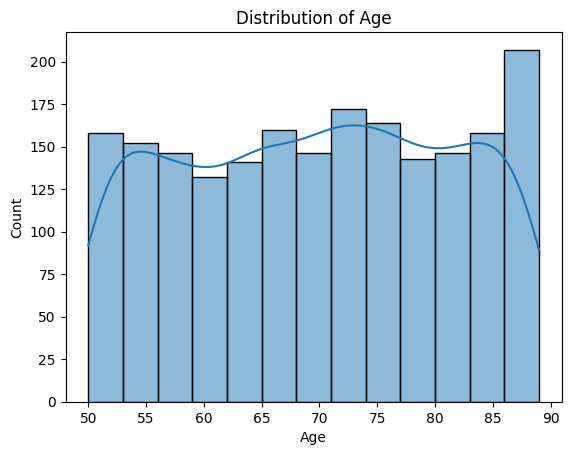

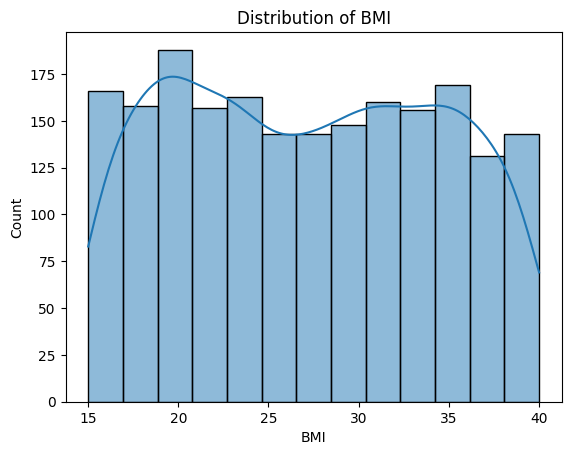

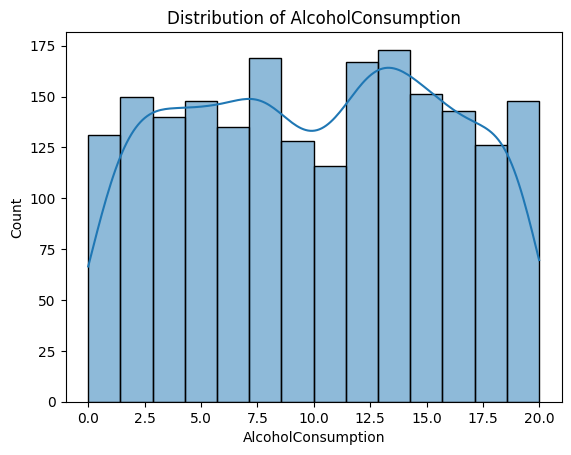

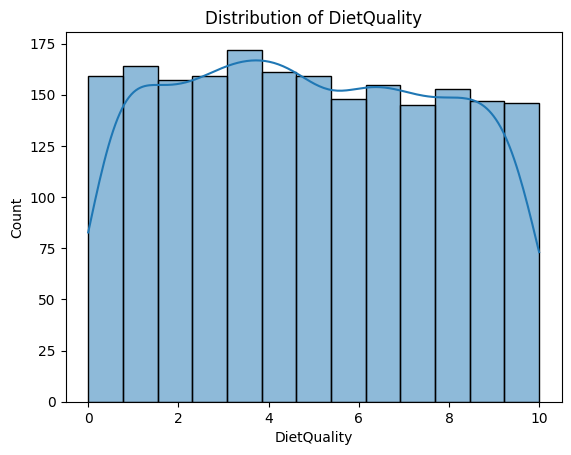

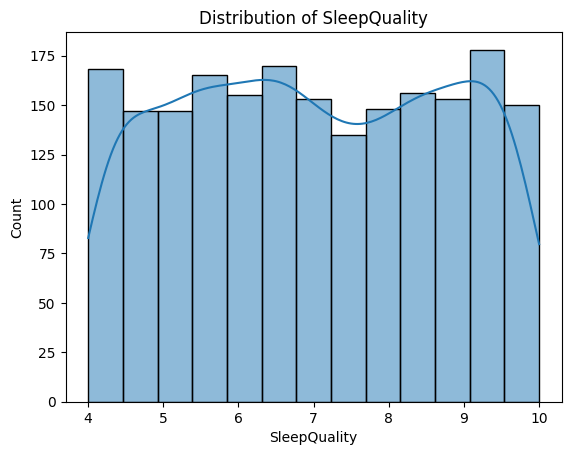

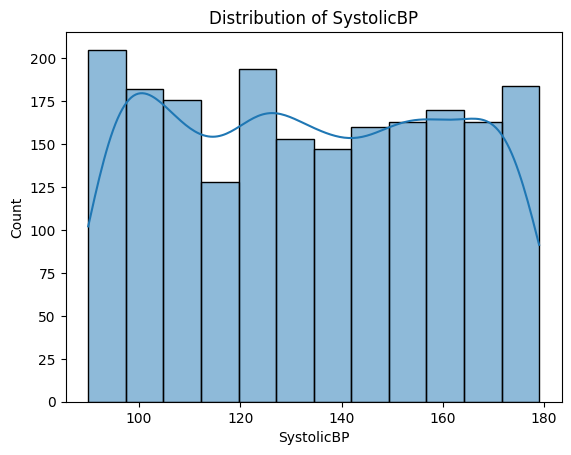

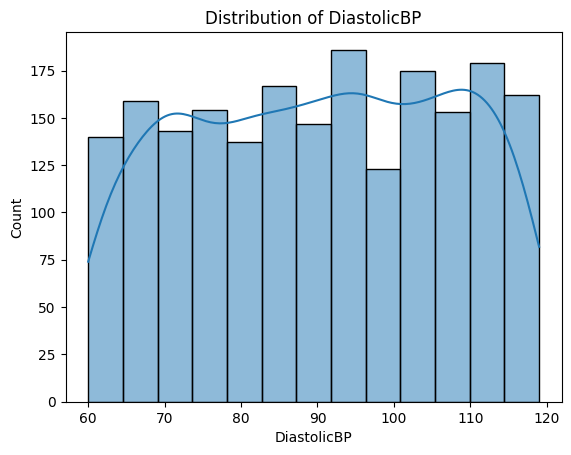

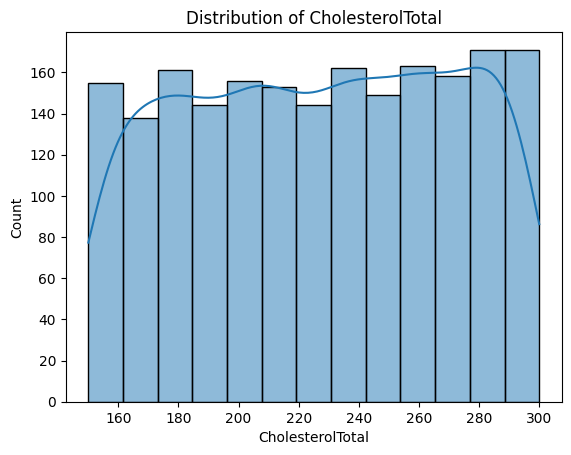

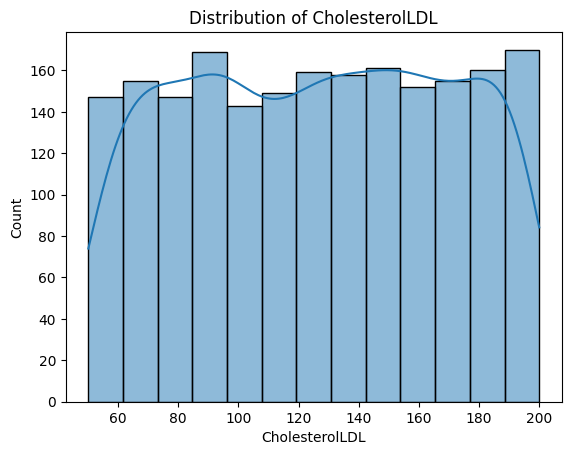

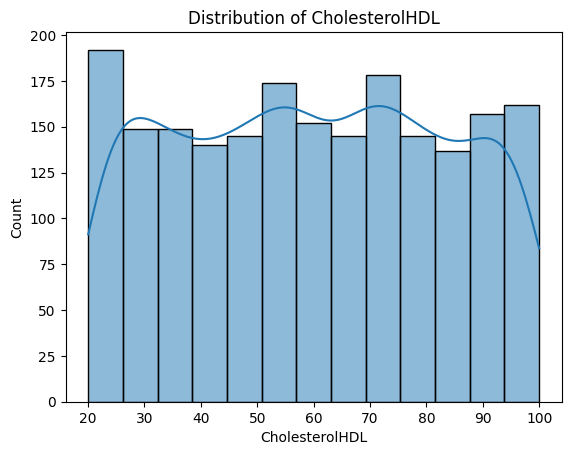

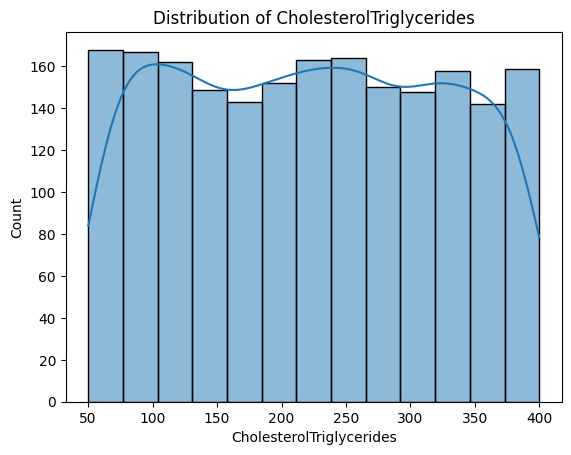

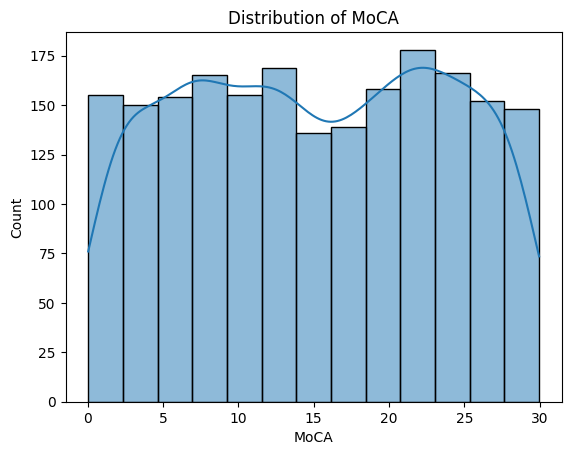

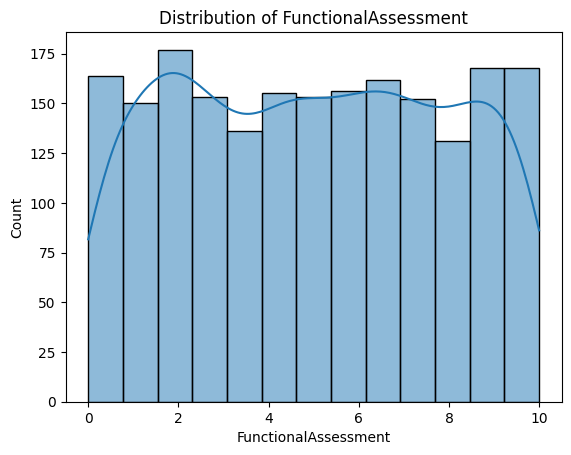

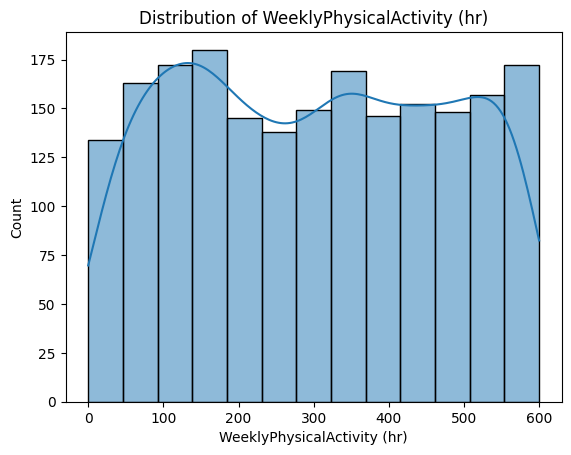

In [ ]:
for col in numerical_cols:
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

##Checking Multicollinearity using Correlation Matrix

- No collinearity was detected in the features.

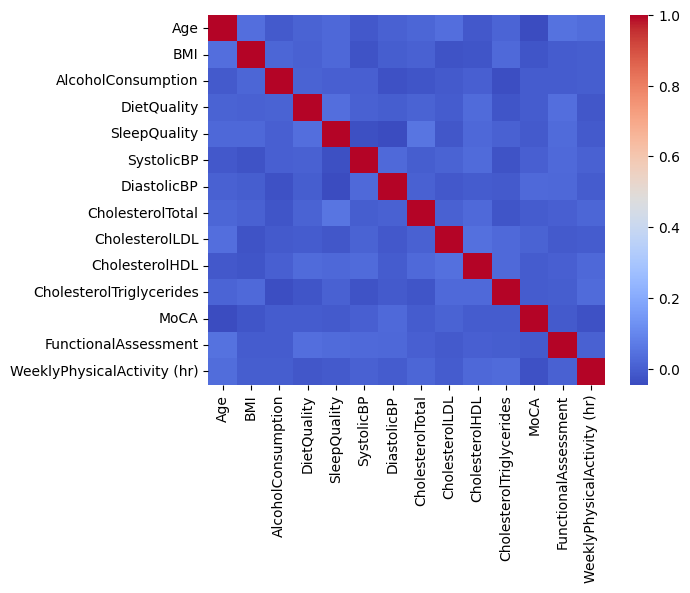

In [ ]:
corr_matrix = data[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.show()

#[9] Preparing Data for Modeling.

## Separate features and target variable


In [ ]:
X=data.drop(columns=['UPDRS'])
y=data['UPDRS']

## Split the data into training and testing sets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling the numerical features

- MinMaxScaler was used because as seen above the data was not normally distributed.


In [ ]:
scaler = MinMaxScaler()

scaler.fit(X_train[numerical_cols])
X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

#[10] Feature Selection

## Select top 20 features using F-test (ANOVA) for regression

We used SelectKBest with f_regression to select the top 20 features most correlated with the target y. Features were ranked by their F-scores, and the 20 highest-scoring features were retained.


In [ ]:
selector = SelectKBest(score_func=f_regression, k=20)
selector.fit(X, y)
top_features = X.columns[selector.get_support()]
scores = selector.scores_[selector.get_support()]
feature_scores = pd.DataFrame({'Feature': top_features, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)


## Feature Selection Visualization  
The bar chart below highlights the most relevant features based on their statistical correlation with the target variable.

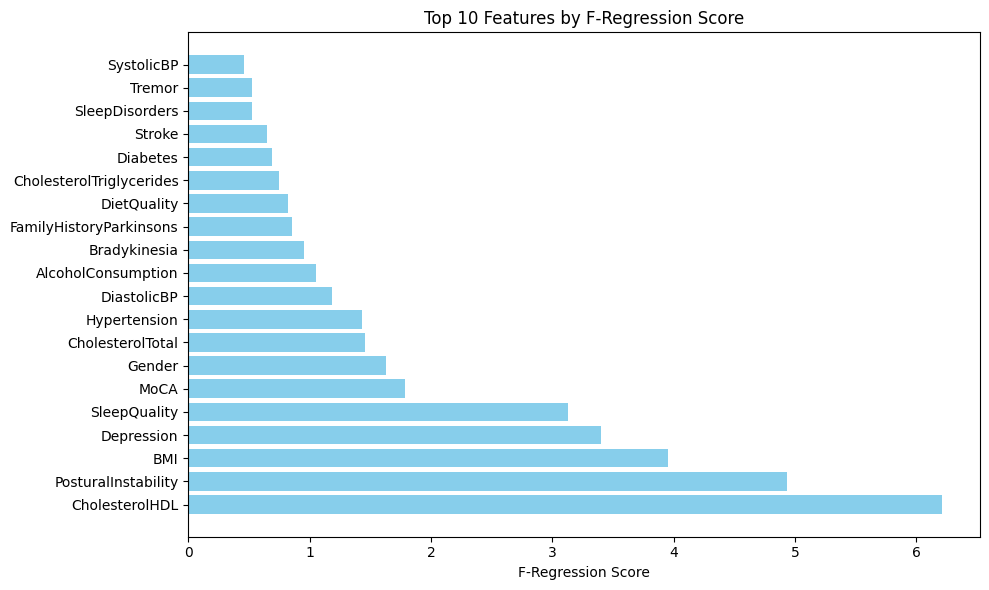

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='skyblue')
plt.xlabel('F-Regression Score')
plt.title('Top 10 Features by F-Regression Score')
plt.tight_layout()
plt.show()

## Top 5 Most Important Features

Based on the feature selection analysis and visualization, the following five features demonstrated the highest relevance to the target variable. These were identified using univariate linear regression tests (f-regression) and are considered the most predictive inputs in the dataset.


In [ ]:
top_5_features = feature_scores['Feature'].head(5).values
print(top_5_features)

['CholesterolHDL' 'PosturalInstability' 'BMI' 'Depression' 'SleepQuality']


# **Modelling**

### Implementing Regression Models
- Choose and implement different regresssion models such as  Polynomial Regression, SVR, XGBOOST..etc
- Improve model using grid search, random search and K cross validation.
- Evaluate the performance of each classifier using metrics like MSE, MAE, r2-score.


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

In [ ]:
X_train = X_train[top_5_features]
X_test = X_test[top_5_features]

# **[1] Polynomial Regression**

## Try Different Polynomial Degrees

In [ ]:

degrees = list(range(1, 7))

train_rmse_list = []
test_rmse_list = []
train_r2_list = []
test_r2_list = []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = model.score(X_train_poly, y_train)
    test_r2 = model.score(X_test_poly, y_test)

    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)



## Check Polynomial Regression Results

In [ ]:

linear_results = pd.DataFrame({
    'Degree': degrees,
    'Train RMSE': train_rmse_list,
    'Test RMSE': test_rmse_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

print("\nPolynomial Regression Results Table:")
print(linear_results.to_string(index=False, float_format="{:.4f}".format))


Polynomial Regression Results Table:
 Degree  Train RMSE  Test RMSE  Train R2  Test R2
      1     56.6051    54.6381    0.0096   0.0101
      2     56.3803    54.8433    0.0174   0.0027
      3     55.9793    55.4653    0.0313  -0.0201
      4     55.1302    56.7208    0.0605  -0.0668
      5     54.2745    56.1217    0.0894  -0.0444
      6     52.8729    86.6848    0.1359  -1.4916


## Plot The  Polynomial Degrees and get the best one

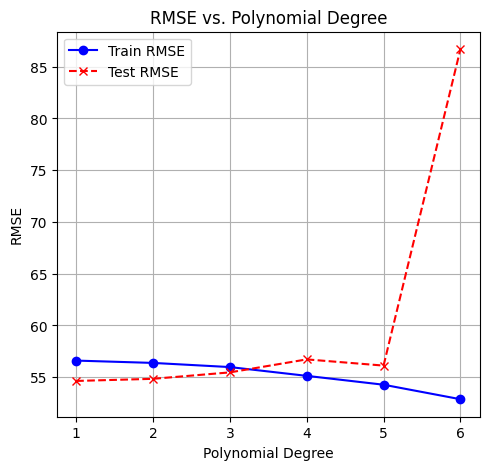

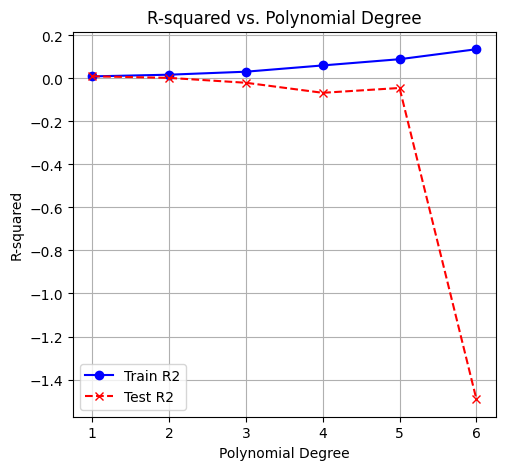


Best polynomial degree: 1


In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees, train_rmse_list, marker='o', label='Train RMSE', color='blue')
plt.plot(degrees, test_rmse_list, marker='x', linestyle='--', label='Test RMSE', color='red')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('RMSE vs. Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(degrees, train_r2_list, marker='o', label='Train R2', color='blue')
plt.plot(degrees, test_r2_list, marker='x', linestyle='--', label='Test R2', color='red')
plt.xlabel('Polynomial Degree')
plt.ylabel('R-squared')
plt.title('R-squared vs. Polynomial Degree')
plt.legend()
plt.grid(True)
plt.show()

best_degree = linear_results.loc[linear_results['Test RMSE'].idxmin(), 'Degree']
print(f"\nBest polynomial degree: {best_degree}")


## Tune Ridge and Lasso Models

In [ ]:

alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]
table_data_tuned = []

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

for model_name in ['Ridge', 'Lasso']:
    if model_name == 'Ridge':
        model = Ridge()
    else:
        model = Lasso()

    param_grid = {'alpha': alpha_values}
    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_search.fit(X_train_poly, y_train)
    best_model = grid_search.best_estimator_
    best_alpha = grid_search.best_params_['alpha']

    y_train_pred = best_model.predict(X_train_poly)
    y_test_pred = best_model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = best_model.score(X_train_poly, y_train)
    test_r2 = best_model.score(X_test_poly, y_test)

    table_data_tuned.append({
        'Model': model_name,
        'Degree': best_degree,
        'Best Alpha': best_alpha,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    })

TuningResults = pd.DataFrame(table_data_tuned)
print("\nTuning Results for Best Degree:")
print(TuningResults.to_string(index=False, float_format="{:.4f}".format))


Tuning Results for Best Degree:
Model  Degree  Best Alpha  Train RMSE  Test RMSE  Train R2  Test R2
Ridge       1    100.0000     56.6490    54.6905    0.0080   0.0082
Lasso       1      0.0100     56.6052    54.6418    0.0096   0.0100


- Best Model declaration: Polynomial Regression(degree=1, Ridge:alpha=100, lasso:alpha=0.01)

#[2] SVR

### Tuning hyper paramters
- kernel: 'linear', 'poly', 'rbf', etc.
- C:	Regularization, larger C = less regularization (fits data more closely).
- epsilon:	Width of the no-penalty tube around the true values.
- gamma:	Controls how far the influence of a single data point reaches (in RBF/poly kernels).

In [ ]:
C_list = [0.005,0.012,0.2,0.1, 1, 2, 10,15, 20,25, 50, 100, 200, 300, 500, 700]
epsilon_list = [0.01, 0.1, 1, 2, 4, 8, 10, 20, 32, 64, 70, 75]
gamma_list = ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10, 50, 60,75, 80, 90,100]

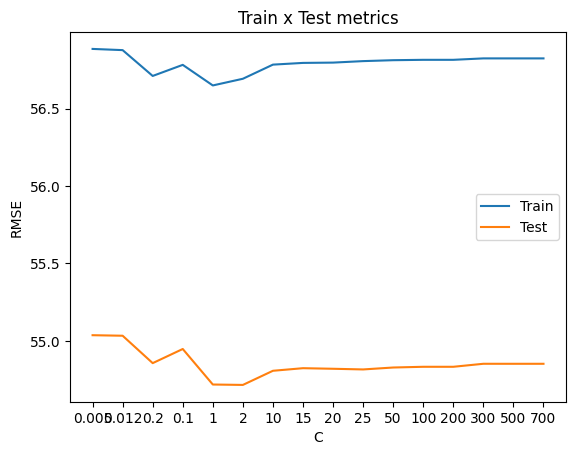

In [ ]:
# First hyper parameter  C

error_list_train = []
error_list_val = []
for C in C_list:
    model = SVR(kernel='linear',C = C).fit(X_train,y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    error_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    error_val = np.sqrt(mean_squared_error(y_test, predictions_val))
    error_list_train.append(error_train)
    error_list_val.append(error_val)

plt.title('Train x Test metrics')
plt.xlabel('C')
plt.ylabel('RMSE')
plt.xticks(ticks = range(len(C_list)),labels=C_list)
plt.plot(error_list_train)
plt.plot(error_list_val)
plt.legend(['Train','Test'])

* we chose C to be 1

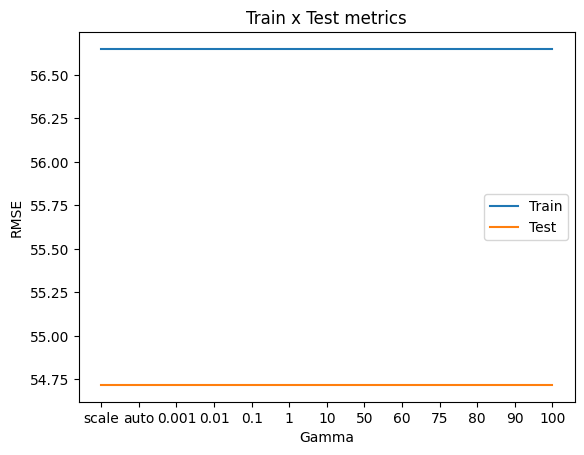

In [ ]:
# Second hyper parameter gamma

error_list_train = []
error_list_val = []
for gamma in gamma_list:
    model = SVR(kernel='linear',C = 1, gamma = gamma).fit(X_train,y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    error_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    error_val = np.sqrt(mean_squared_error(y_test, predictions_val))
    error_list_train.append(error_train)
    error_list_val.append(error_val)

plt.title('Train x Test metrics')
plt.xlabel('Gamma')
plt.ylabel('RMSE')
plt.xticks(ticks = range(len(gamma_list)),labels=gamma_list)
plt.plot(error_list_train)
plt.plot(error_list_val)
plt.legend(['Train','Test'])

* we choose gamma to be 0.01


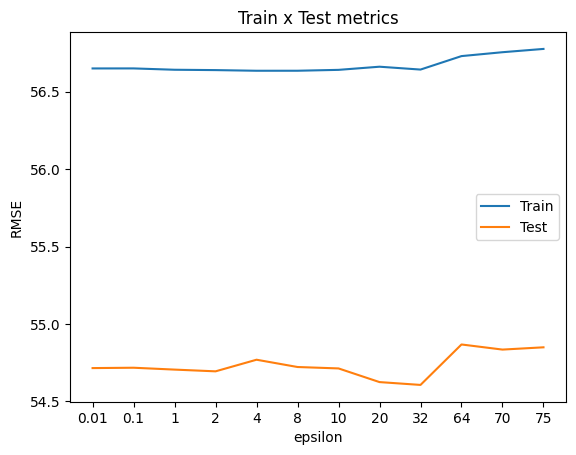

In [ ]:
# Third hyper parameter epsilon

error_list_train = []
error_list_val = []
for ep in epsilon_list:
    model = SVR(kernel='linear',C = 1,gamma = 0.01, epsilon = ep).fit(X_train,y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    error_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    error_val = np.sqrt(mean_squared_error(y_test, predictions_val))
    error_list_train.append(error_train)
    error_list_val.append(error_val)

plt.title('Train x Test metrics')
plt.xlabel('epsilon')
plt.ylabel('RMSE')
plt.xticks(ticks = range(len(epsilon_list)),labels=epsilon_list)
plt.plot(error_list_train)
plt.plot(error_list_val)
plt.legend(['Train','Test'])

* we chose epsilon to be 32

## Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_predict
svm_model = SVR(kernel='rbf', C=1, gamma=0.01, epsilon=32)

y_pred = cross_val_predict(svm_model, X_train, y_train, cv=7)

mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print("Cross-Validation Metrics:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

Cross-Validation Metrics:
MSE: 3245.1196
RMSE: 56.9660
MAE: 49.1182
R2 Score: -0.0031


In [ ]:
svm_model.fit(X_train, y_train)

y_pred=svm_model.predict(X_test)
y_pred_train=svm_model.predict(X_train)

# For training data
print(f"Metrics Train:")
print(f"\tRMSE: { np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"\tR2 Score: {r2_score(y_train, y_pred_train):.2f}")

# For test data
print(f"Metrics Test:")
print(f"\tRMSE: { np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"\tR2 Score: {r2_score(y_test, y_pred):.2f}")

Metrics Train:
	RMSE: 56.86
	MAE: 49.03
	R2 Score: 0.00
Metrics Test:
	RMSE: 54.95
	MAE: 46.87
	R2 Score: -0.00


## GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel':  ['rbf', 'linear']
}

svm_model = SVR()

grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, n_jobs=4 ,scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=4,
             param_grid={'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1, 0.5],
                         'gamma': ['scale', 0.01, 0.1, 1],
                         'kernel': ['rbf', 'linear']},
             scoring='neg_mean_squared_error')

In [ ]:
print("Mean cross-validation scores:")
means=grid_search.cv_results_['mean_test_score']
params=grid_search.cv_results_['params']

for mean_score, param in zip(means, params):
 print(f"{mean_score:.3f} for {param}")

Mean cross-validation scores:
-3231.034 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
-3233.187 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
-3239.300 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
-3233.187 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'linear'}
-3238.284 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}
-3233.187 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'linear'}
-3231.863 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 1, 'kernel': 'rbf'}
-3233.187 for {'C': 0.1, 'epsilon': 0.01, 'gamma': 1, 'kernel': 'linear'}
-3230.787 for {'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
-3233.020 for {'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
-3239.256 for {'C': 0.1, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
-3233.020 for {'C': 0.1, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
-3238.396 for {'C': 0.1, 'epsilon': 0.1, 'gamma': 0.1, 'kernel':

In [ ]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'C': 1, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best Score: -3225.166501673821


In [ ]:
svm_model = SVR(kernel='rbf', C=1, gamma=1, epsilon=0.1)
svm_model.fit(X_train,y_train)

y_pred=svm_model.predict(X_test)
y_pred_train=svm_model.predict(X_train)

# For training data
print(f"Metrics Train:")
print(f"\tMSE: { np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"\tR2 Score: {r2_score(y_train, y_pred_train):.2f}")

# For test data
print(f"Metrics Test:")
print(f"\tMSE: { np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"\tR2 Score: {r2_score(y_test, y_pred):.2f}")

Metrics Train:
	MSE: 56.50
	MAE: 48.43
	R2 Score: 0.01
Metrics Test:
	MSE: 54.87
	MAE: 46.90
	R2 Score: 0.00


## Performance Evaluation

- After comparing both RMSE of both graphs&cross validation and gridsearch.

- The best RMSE is 54.87 from gridsearchCv.




- Best Model declaraion: SVR(kernel='rbf', C=1, gamma=1, epsilon=0.1)

#[3] XGBOOST


### Tuning hyper paramters
- n_estimators: number of trees (more = better performance, but risk of overfitting).

- learning_rate: step size shrinkage. Lower = more accurate, but slower training.

- max_depth: controls tree depth. Higher = more complex model.


In [ ]:
learning_rate_list = [0.0000001,0.000001,0.005,0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1]
max_depth_list = [2, 3, 4, 5, 6, 7, 8, 10, 12,13,14,15]
n_estimators_list = [50, 100, 200, 300, 400, 500, 700, 1000,2000,28000,50000]

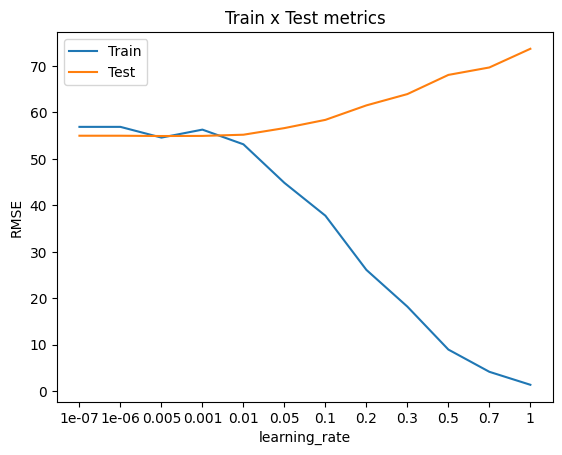

In [ ]:
# First hyper parameter learning rate

error_list_train = []
error_list_val = []
for l in learning_rate_list:
    model = XGBRegressor(learning_rate = l).fit(X_train,y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    error_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    error_val = np.sqrt(mean_squared_error(y_test, predictions_val))
    error_list_train.append(error_train)
    error_list_val.append(error_val)

plt.title('Train x Test metrics')
plt.xlabel('learning_rate')
plt.ylabel('RMSE')
plt.xticks(ticks = range(len(learning_rate_list)),labels=learning_rate_list)
plt.plot(error_list_train)
plt.plot(error_list_val)
plt.legend(['Train','Test'])

* we chose learning rate to be 0.0000001

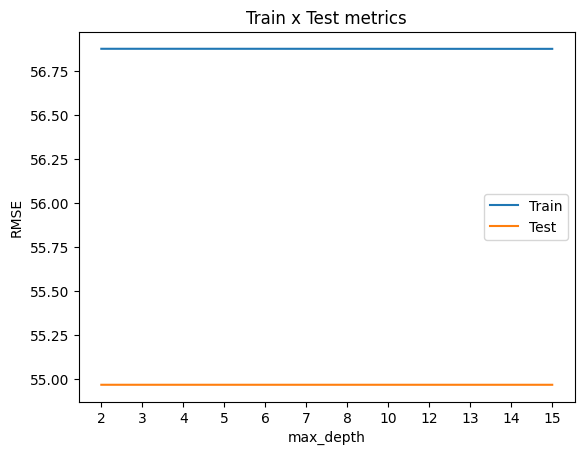

In [ ]:
# second hyper parameter depth

error_list_train = []
error_list_val = []
for m in max_depth_list:
    model = XGBRegressor(learning_rate = 0.0000001, max_depth = m).fit(X_train,y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    error_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    error_val = np.sqrt(mean_squared_error(y_test, predictions_val))
    error_list_train.append(error_train)
    error_list_val.append(error_val)

plt.title('Train x Test metrics')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.xticks(ticks = range(len(max_depth_list)),labels=max_depth_list)
plt.plot(error_list_train)
plt.plot(error_list_val)
plt.legend(['Train','Test'])

* we chose max_depth to be 6

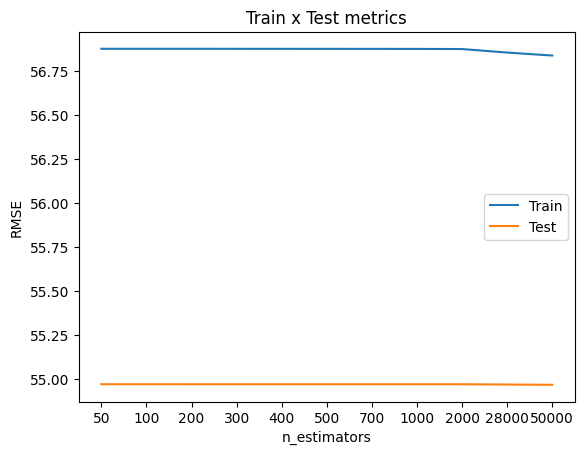

In [ ]:
# Third hyper parameter n_estimators

error_list_train = []
error_list_val = []
for n in n_estimators_list:
    model = XGBRegressor(learning_rate =0.0000001, max_depth = 6,n_estimators = n).fit(X_train,y_train)
    predictions_train = model.predict(X_train)
    predictions_val = model.predict(X_test)

    error_train = np.sqrt(mean_squared_error(y_train, predictions_train))
    error_val = np.sqrt(mean_squared_error(y_test, predictions_val))
    error_list_train.append(error_train)
    error_list_val.append(error_val)

plt.title('Train x Test metrics')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.xticks(ticks = range(len(n_estimators_list)),labels=n_estimators_list)
plt.plot(error_list_train)
plt.plot(error_list_val)
plt.legend(['Train','Test'])

* we chose n_estimators to be 200

## Cross Validation

In [ ]:
xgb_model = XGBRegressor(learning_rate =0.0000001, max_depth = 6,n_estimators = 200)

y_pred = cross_val_predict(xgb_model, X_train, y_train, cv=7)

mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print("Cross-Validation Metrics:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

Cross-Validation Metrics:
MSE: 3243.8403
RMSE: 56.9547
MAE: 49.1169
R2 Score: -0.0027


In [ ]:
xgb_model.fit(X_train, y_train)

y_pred=xgb_model.predict(X_test)
y_pred_train=xgb_model.predict(X_train)

# For training data
print(f"Metrics Train:")
print(f"\tRMSE: { np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"\tR2 Score: {r2_score(y_train, y_pred_train):.2f}")

# For test data
print(f"Metrics Test:")
print(f"\tRMSE: { np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"\tR2 Score: {r2_score(y_test, y_pred):.2f}")

Metrics Train:
	RMSE: 56.88
	MAE: 49.06
	R2 Score: 0.00
Metrics Test:
	RMSE: 54.97
	MAE: 46.88
	R2 Score: -0.00


## GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9]
}
xgb_model = XGBRegressor()

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7, 9],
                         'n_estimators': [100, 200, 300, 500]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
print("Mean cross-validation scores:")
means=grid_search.cv_results_['mean_test_score']
params=grid_search.cv_results_['params']

for mean_score, param in zip(means, params):
 print(f"{mean_score:.3f} for {param}")

Mean cross-validation scores:
-3234.928 for {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 100}
-3233.459 for {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 200}
-3232.489 for {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 300}
-3230.978 for {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 500}
-3238.989 for {'learning_rate': 0.001, 'max_depth': 5, 'n_estimators': 100}
-3239.492 for {'learning_rate': 0.001, 'max_depth': 5, 'n_estimators': 200}
-3241.199 for {'learning_rate': 0.001, 'max_depth': 5, 'n_estimators': 300}
-3244.219 for {'learning_rate': 0.001, 'max_depth': 5, 'n_estimators': 500}
-3241.138 for {'learning_rate': 0.001, 'max_depth': 7, 'n_estimators': 100}
-3247.711 for {'learning_rate': 0.001, 'max_depth': 7, 'n_estimators': 200}
-3253.140 for {'learning_rate': 0.001, 'max_depth': 7, 'n_estimators': 300}
-3268.675 for {'learning_rate': 0.001, 'max_depth': 7, 'n_estimators': 500}
-3239.723 for {'learning_rate': 0.001, 'max_depth': 9, 'n_

In [ ]:
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 500}
Best Score: -3230.9778681642765


In [ ]:
xgb_model = XGBRegressor(learning_rate =0.001, max_depth = 3,n_estimators = 500)
xgb_model.fit(X_train,y_train)

y_pred=xgb_model.predict(X_test)
y_pred_train=xgb_model.predict(X_train)

# For training data
print(f"Metrics Train:")
print(f"\tRMSE: { np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"\tR2 Score: {r2_score(y_train, y_pred_train):.2f}")

# For test data
print(f"Metrics Test:")
print(f"\tRMSE: { np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"\tMAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"\tR2 Score: {r2_score(y_test, y_pred):.2f}")

Metrics Train:
	RMSE: 56.23
	MAE: 48.42
	R2 Score: 0.02
Metrics Test:
	RMSE: 54.79
	MAE: 46.82
	R2 Score: 0.00


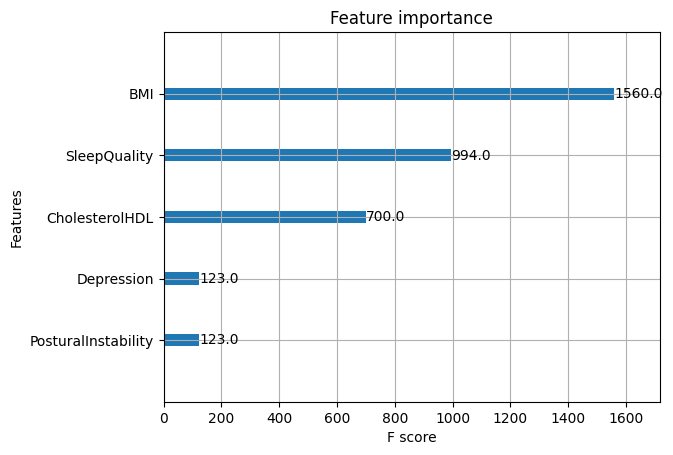

In [ ]:
import xgboost as xgb

xgb.plot_importance(xgb_model)
plt.show()

## Performance Evaluation

- After comparing both RMSE of both graphs&cross validation and gridsearch.

- The best RMSE is 54.79 from both approaches.

- Best Model declaraion: xgb_model = XGBRegressor(learning_rate =0.001, max_depth = 3,n_estimators = 500)

#[4] Decision Tree Regressor

### Tuning hyper paramters
- max_depth :
This hyperparameter determines the maximum depth of the decision tree

- min_samples_split :
This hyperparameter determines the minimum number of samples required to split an internal node during the construction of the decision tree

- min_samples_leaf :
This hyperparameter determines the minimum number of samples required to be at a leaf node.

- max_features
This hyperparameter determines the maximum number of features the model can consider when looking for the best split.


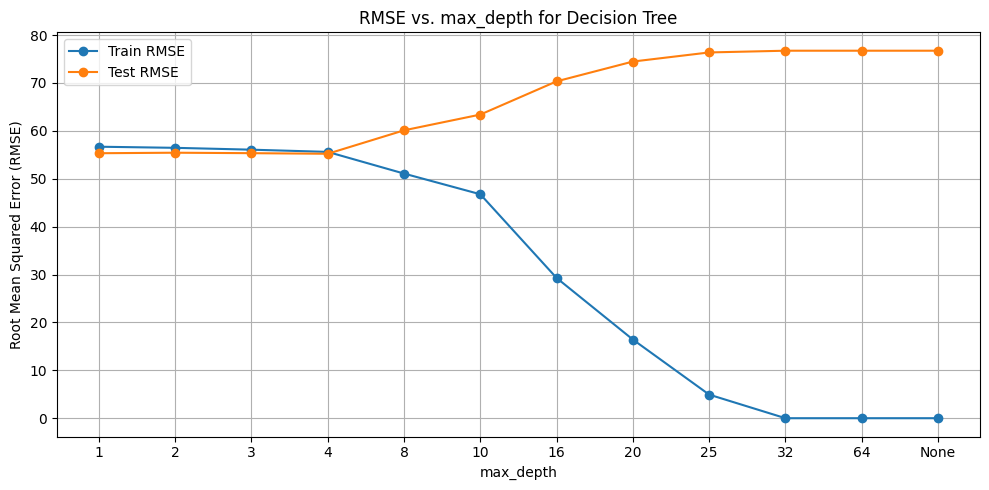

In [ ]:
X_train_selected = X_train
X_test_selected = X_test

from sklearn.tree import DecisionTreeRegressor

depth_values = [1, 2, 3, 4, 8, 10, 16, 20, 25, 32, 64, None]
train_errors = []
test_errors = []

for depth in depth_values:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in depth_values], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in depth_values], test_errors, label="Test RMSE", marker='o')
plt.xlabel("max_depth")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. max_depth for Decision Tree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


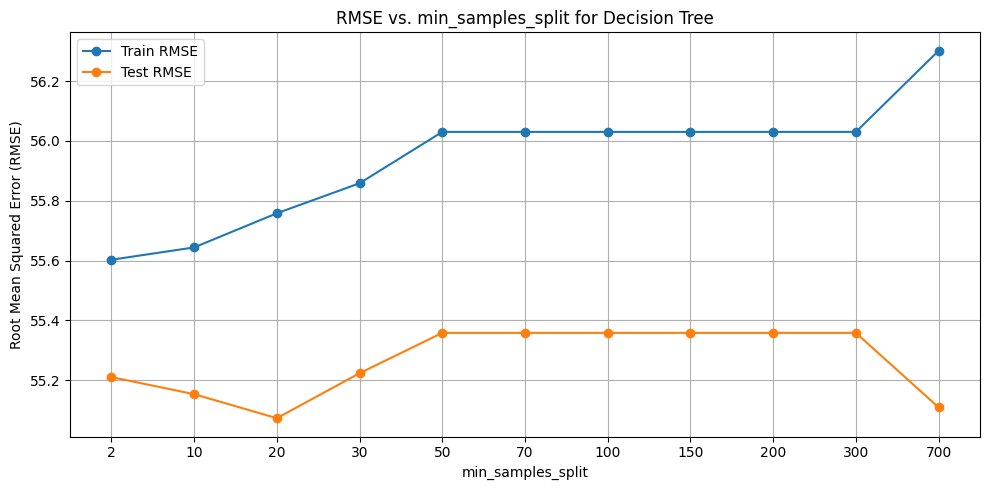

In [ ]:
min_samples_split_list = [2,10,20, 30, 50,70, 100,150, 200, 300, 700]
train_errors = []
test_errors = []

for split in min_samples_split_list:
    model = DecisionTreeRegressor(
        max_depth=4,
        min_samples_split=split,
        random_state=42
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in min_samples_split_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in min_samples_split_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("min_samples_split")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. min_samples_split for Decision Tree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- The best min samples split is 20 as it has lowest test rmse with train rmse reasonably low

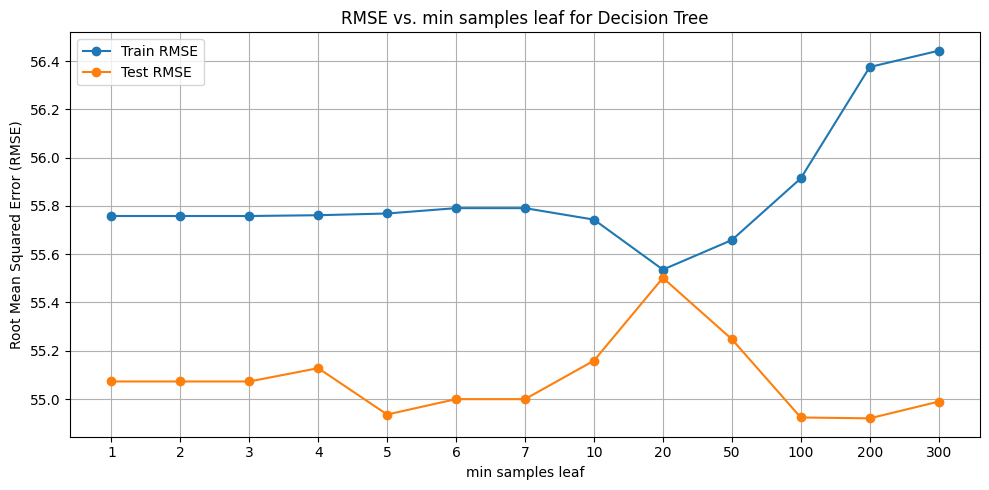

In [ ]:
min_samples_leaf_list = [1, 2,3,4,5,6,7, 10, 20, 50, 100,200,300]
train_errors = []
test_errors = []

for minLeaf in min_samples_leaf_list:
    model = DecisionTreeRegressor(
        max_depth=4,
        min_samples_split=20,
        min_samples_leaf=minLeaf,
        random_state=42
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in min_samples_leaf_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in min_samples_leaf_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("min samples leaf")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. min samples leaf for Decision Tree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
dt_regressor = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=20,
    min_samples_split=20,
    random_state=42
)

dt_regressor.fit(X_train_selected, y_train)

print("Decision Tree TRAIN ERROR")
dt_y_pred_train = dt_regressor.predict(X_train_selected)
print(np.sqrt(mean_squared_error(y_train, dt_y_pred_train)))

print(f"train R2 Score: {r2_score(y_train, dt_y_pred_train):.2f}")

print("Decision Tree TEST ERROR")
dt_y_pred_test = dt_regressor.predict(X_test_selected)
print(np.sqrt(mean_squared_error(y_test, dt_y_pred_test)))
print(f"test R2 Score: {r2_score(y_test, dt_y_pred_test):.2f}")

Decision Tree TRAIN ERROR
55.53610062227974
train R2 Score: 0.05
Decision Tree TEST ERROR
55.501966214445176
test R2 Score: -0.02


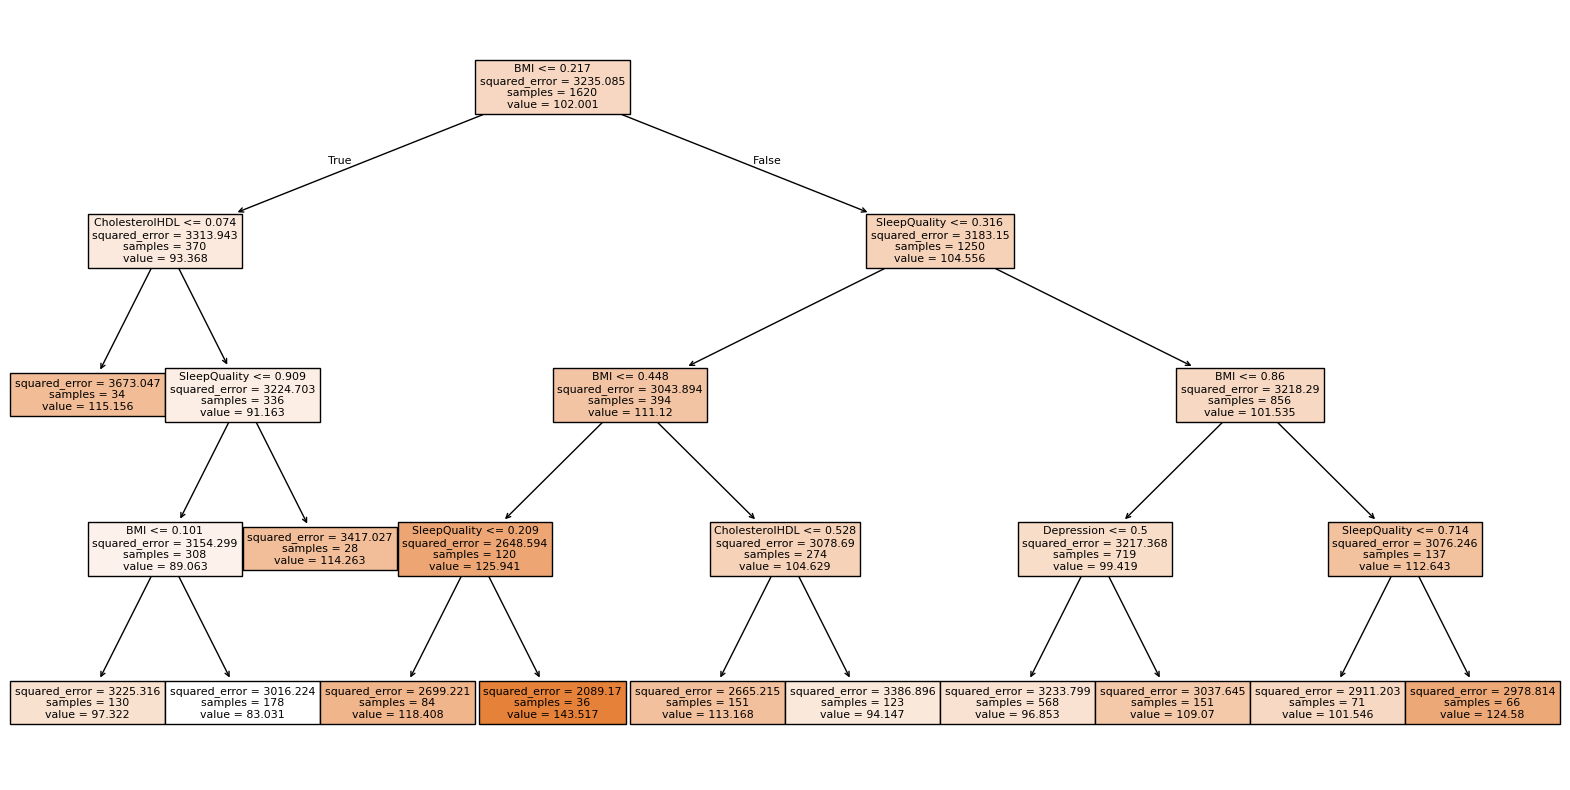

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(dt_regressor, filled=True, feature_names=X_train_selected.columns)
plt.show()

### Hyperparameter tuning using grid search

In [ ]:
from sklearn.model_selection import GridSearchCV

DT = DecisionTreeRegressor(random_state=42)
param_grid = {
    'max_depth': [None,3,4, 5, 10, 20, 30],
    'min_samples_split': [1,2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

GS = GridSearchCV(estimator=DT, param_grid=param_grid, cv=5, n_jobs=-1, scoring=['neg_root_mean_squared_error','r2'],refit ='neg_root_mean_squared_error',verbose = 4 )
GS.fit(X_train_selected, y_train)

best_params = GS.best_params_
print("Best Hyperparameters:", best_params)

best_model = GS.best_estimator_
y_pred_test = best_model.predict(X_test_selected)
y_pred_train = best_model.predict(X_train_selected)

print("TRAIN ERROR AFTER TUINING ", np.sqrt(mean_squared_error(y_train,y_pred_train)))
print("TEST ERROR AFTER TUINING ", np.sqrt(mean_squared_error(y_test,y_pred_test)))


Fitting 5 folds for each of 336 candidates, totalling 1680 fits
Best Hyperparameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}
TRAIN ERROR AFTER TUINING  56.33114768729369
TEST ERROR AFTER TUINING  54.813725023229146


Best Hyperparameters: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}

In [ ]:
dt = DecisionTreeRegressor(
    max_depth=3,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train_selected, y_train)

print("Decision Tree TRAIN ERROR")
dt_y_pred_train = dt.predict(X_train_selected)
print(np.sqrt(mean_squared_error(y_train, dt_y_pred_train)))
print(f"train R2 Score: {r2_score(y_train, dt_y_pred_train)}")

print("Decision Tree TEST ERROR")
dt_y_pred_test = dt.predict(X_test_selected)
print(np.sqrt(mean_squared_error(y_test, dt_y_pred_test)))
print(f"test R2 Score: {r2_score(y_test, dt_y_pred_test)}")

Decision Tree TRAIN ERROR
56.33114768729369
train R2 Score: 0.01912988376729674
Decision Tree TEST ERROR
54.813725023229146
test R2 Score: 0.0037422136542825113


## Performance Evaluation

Best rmse for Decision Tree is: 54.81 (from grid search)

- Best Model declaraion:
DecisionTreeRegressor(
    max_depth=3,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=10,
    random_state=42
)

#[5] Random Forest Regressor

### Tuning hyper paramters

-  n_estimators :
The number of decision trees in the random forest.

-  max_depth :
The maximum depth of each decision tree in the forest.

-  min_samples_leaf :
The minimum number of samples required to be at a leaf node.

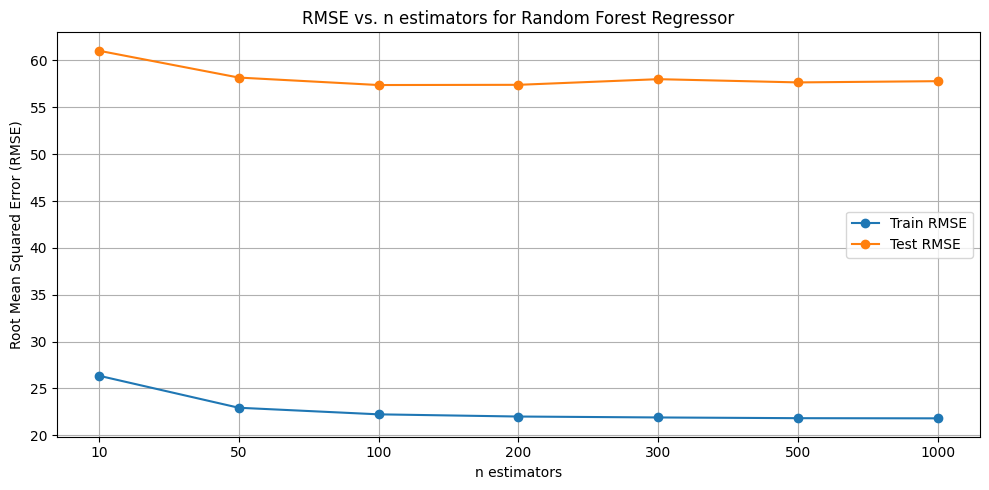

In [ ]:
from sklearn.ensemble import RandomForestRegressor

n_estimators_list = [10, 50, 100, 200, 300, 500, 1000]

train_errors = []
test_errors = []

for n in n_estimators_list:
    model = RandomForestRegressor(
        bootstrap=True,
        n_estimators=n
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in n_estimators_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in n_estimators_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("n estimators")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. n estimators for Random Forest Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

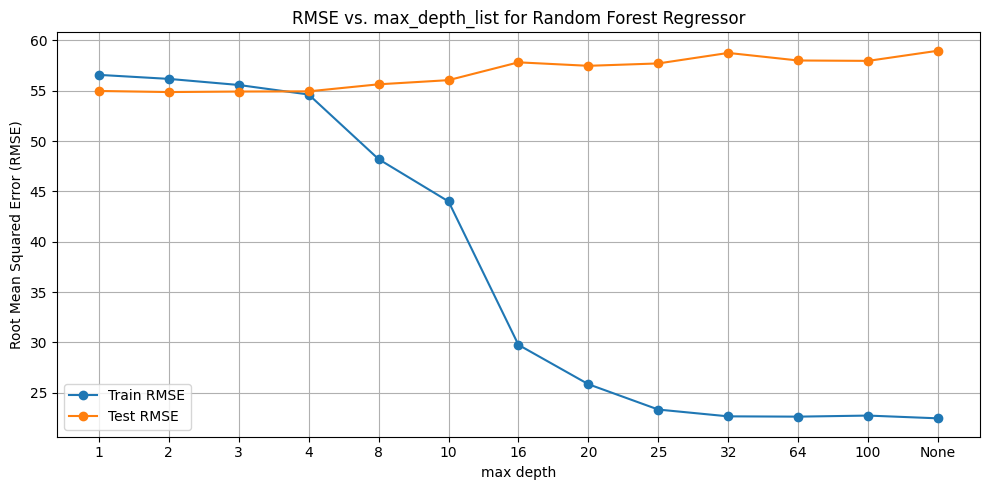

In [ ]:
max_depth_list = [1,2, 3, 4,8,10,16,20,25, 32, 64,100, None]
train_errors = []
test_errors = []

for max in max_depth_list:
    model = RandomForestRegressor(
        bootstrap=True,
        n_estimators=50,
        max_depth=max
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in max_depth_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in max_depth_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("max depth")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. max_depth_list for Random Forest Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

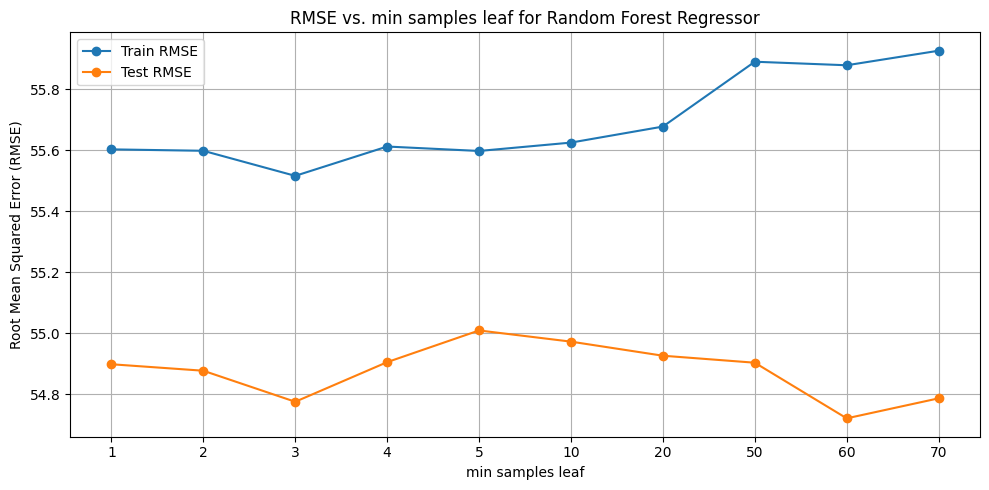

In [ ]:
min_samples_leaf_list = [1, 2,3,4, 5, 10, 20, 50,60,70]
train_errors = []
test_errors = []

for min in min_samples_leaf_list:
    model = RandomForestRegressor(
        bootstrap=True,
        n_estimators=50,
        max_depth=3,
        min_samples_leaf=min
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in min_samples_leaf_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in min_samples_leaf_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("min samples leaf")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. min samples leaf for Random Forest Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
RF = RandomForestRegressor(
    bootstrap=True,
    max_depth=3,
    min_samples_leaf=3,
    n_estimators=50
)

RF.fit(X_train_selected, y_train)

print("Random Forest TRAIN ERROR")
rf_y_pred_train = RF.predict(X_train_selected)
print(np.sqrt(mean_squared_error(y_train, rf_y_pred_train)))
print(f"train R2 Score: {r2_score(y_train, rf_y_pred_train):.2f}")

print("Random Forest TEST ERROR")
rf_y_pred_test = RF.predict(X_test_selected)
print(np.sqrt(mean_squared_error(y_test, rf_y_pred_test)))
print(f"test R2 Score: {r2_score(y_test, rf_y_pred_test):.2f}")

Random Forest TRAIN ERROR
55.601896599950756
train R2 Score: 0.04
Random Forest TEST ERROR
54.828459269915555
test R2 Score: 0.00


### Hyperparameter tuning using grid search

In [ ]:
RFR = RandomForestRegressor(
    bootstrap=True)
param_grid = {
    'n_estimators': [200, 300,400],
    'max_depth': [3,5,7, 10],
    'min_samples_split': [10,12,14],
    'min_samples_leaf': [4,5,6],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=RFR, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error', verbose=2)

grid_search.fit(X_train_selected, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_selected)
print("TEST ERROR AFTER TUNING")
np.sqrt(mean_squared_error(y_test,y_pred))

y_pred_train = best_model.predict(X_train_selected)
print("TRAIN ERROR AFTER TUNING")
np.sqrt(mean_squared_error(y_train,y_pred_train))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
TEST ERROR AFTER TUNING
TRAIN ERROR AFTER TUNING


np.float64(55.59018343335044)

Best Parameters: {'bootstrap': True, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 14, 'n_estimators': 300}

In [ ]:
bestRF = RandomForestRegressor(
    bootstrap=True,
    max_depth=3,
    min_samples_leaf=4,
    min_samples_split=14,
    n_estimators=300
)

bestRF.fit(X_train_selected, y_train)

print("Random Forest TRAIN ERROR")
rf_y_pred_train = bestRF.predict(X_train_selected)
print(np.sqrt(mean_squared_error(y_train, rf_y_pred_train)))
print(f"\ train R2 Score: {r2_score(y_train, rf_y_pred_train):.2f}")

print("Random Forest TEST ERROR")
rf_y_pred_test = bestRF.predict(X_test_selected)
print(np.sqrt(mean_squared_error(y_test, rf_y_pred_test)))
print(f"\ test R2 Score: {r2_score(y_test, rf_y_pred_test):.2f}")

Random Forest TRAIN ERROR
55.568669846689964
\ train R2 Score: 0.05
Random Forest TEST ERROR
54.99538005423168
\ test R2 Score: -0.00


## Performance Evaluation

Best Rmse for Random Forest is : 54.84 (from grid search)

- Best Model declaraion:
RandomForestRegressor(
    bootstrap=True,
    max_depth=3,
    min_samples_leaf=4,
    min_samples_split=14,
    n_estimators=300
)

#[6] LightGBM

### Tuning hyper paramters

- learning_rate: Controls how much each tree contributes to the final prediction. A lower value generally improves the model's performance but requires more trees (n_estimators).

- n_estimators: The number of boosting rounds (trees) to build. It’s important to balance this with the learning_rate to avoid overfitting or underfitting.

- num_leaves: Defines the maximum number of leaves in a tree. A larger value allows the model to capture more complex patterns, but can lead to overfitting if too large.

In [ ]:
# !pip install lightgbm # Uncomment if running for the first time or in a new session
from lightgbm import LGBMRegressor

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1

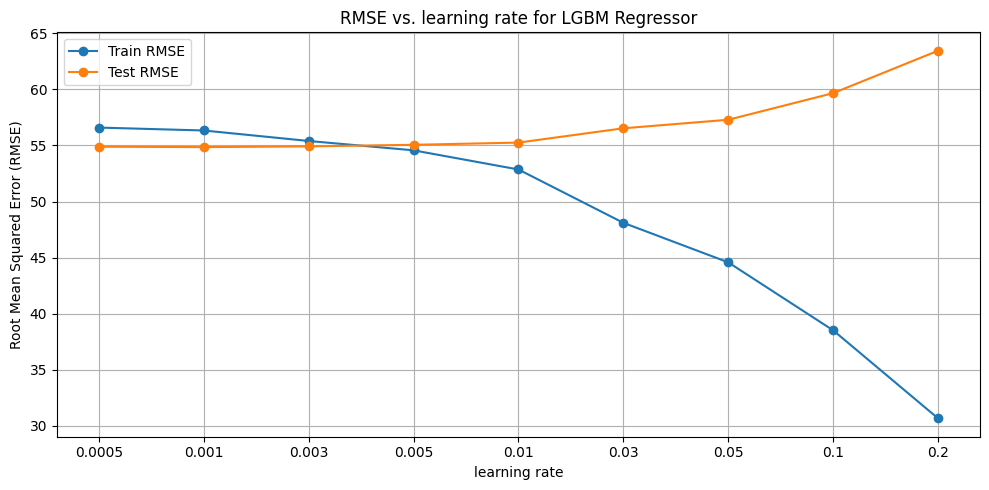

In [ ]:
learning_rate_list = [0.0005,0.001,0.003,0.005, 0.01, 0.03, 0.05, 0.1, 0.2]
train_errors = []
test_errors = []

for l in learning_rate_list:
    model = LGBMRegressor(
        learning_rate=l,
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in learning_rate_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in learning_rate_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("learning rate")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. learning rate for LGBM Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training

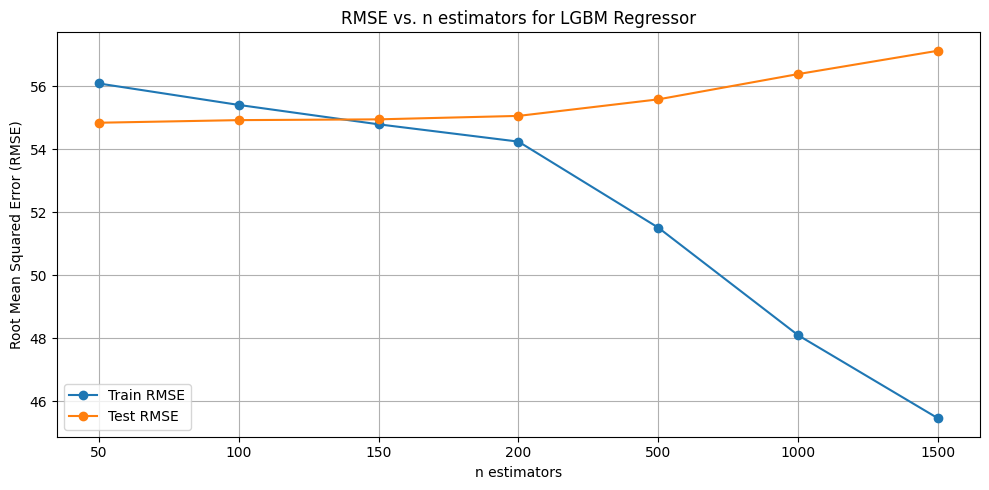

In [ ]:
n_estimators_list = [50, 100,150, 200, 500, 1000, 1500]
train_errors = []
test_errors = []

for n in n_estimators_list:
    model = LGBMRegressor(
        learning_rate=0.003,
         n_estimators=n,

    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in n_estimators_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in n_estimators_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("n estimators")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. n estimators for LGBM Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training

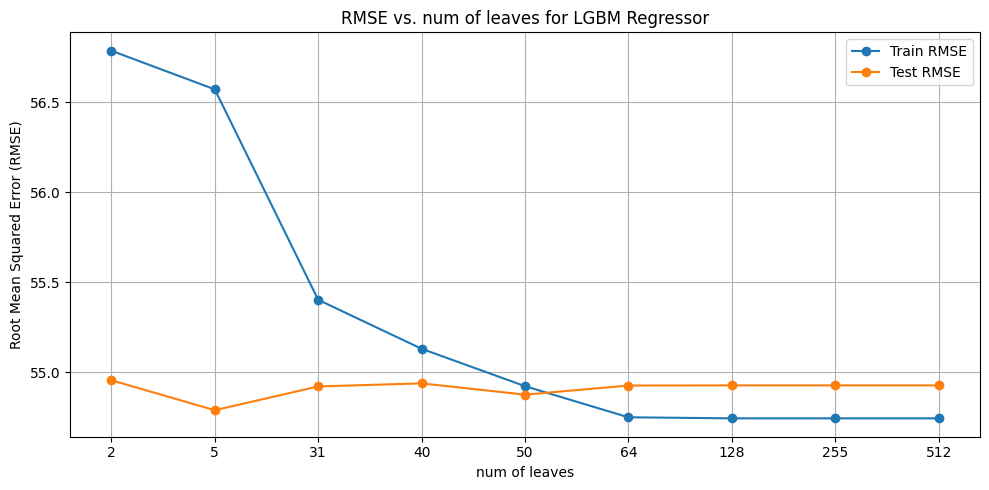

In [ ]:
num_leaves_list = [2,5,31,40, 50, 64, 128, 255, 512]
train_errors = []
test_errors = []

for n in num_leaves_list:
    model = LGBMRegressor(
        learning_rate=0.003,
        n_estimators=100,
        num_leaves=n
    )
    model.fit(X_train_selected, y_train)

    y_pred_train = model.predict(X_train_selected)
    y_pred_test = model.predict(X_test_selected)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in num_leaves_list], train_errors, label="Train RMSE", marker='o')
plt.plot([str(d) for d in num_leaves_list], test_errors, label="Test RMSE", marker='o')
plt.xlabel("num of leaves")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("RMSE vs. num of leaves for LGBM Regressor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
LGBM = LGBMRegressor(
    learning_rate=0.003,
    n_estimators=100,
    num_leaves=50
)

LGBM.fit(X_train_selected, y_train)

print("BEST LGBM TRAIN ERROR")
LGBM_y_pred_train = LGBM.predict(X_train_selected)
print(np.sqrt(mean_squared_error(y_train, LGBM_y_pred_train)))
print(f" train R2 Score: {r2_score(y_train, LGBM_y_pred_train):.2f}")

print("BEST LGBM TEST ERROR")
LGBM_y_pred_test = LGBM.predict(X_test_selected)
print(np.sqrt(mean_squared_error(y_test, LGBM_y_pred_test)))
print(f" test R2 Score: {r2_score(y_test, LGBM_y_pred_test):.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
BEST LGBM TRAIN ERROR
54.92105836797241
 train R2 Score: 0.07
BEST LGBM TEST ERROR
54.87399114020697
 test R2 Score: 0.00


### Hyperparameter tuning using grid search

In [ ]:
LGBMGS = LGBMRegressor()
param_grid = {
    'n_estimators': [50,100, 200],
    'learning_rate': [0.001,0.01,0.05, 0.1, 0.2],
    'max_depth': [-1,1,3, 5, 7],
    'num_leaves': [5,10,20, 31, 40],
}

grid_search = GridSearchCV(estimator=LGBMGS, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error', verbose=1, n_jobs=-1)

grid_search.fit(X_train_selected, y_train)

best_lgbm = grid_search.best_estimator_

print("LGBM TRAIN ERROR")
LGBM_y_pred_train = best_lgbm.predict(X_train_selected)
print(np.sqrt(mean_squared_error(y_train, LGBM_y_pred_train)))

LGBM_y_pred_test = best_lgbm.predict(X_test_selected)
print("LGBM TEST ERROR")
print(np.sqrt(mean_squared_error(y_test, LGBM_y_pred_test)))

print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 375 candidates, totalling 1875 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

Best Parameters: {'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 100, 'num_leaves': 5}

In [ ]:
BEST_LGBM = LGBMRegressor(
     learning_rate=0.01,
    max_depth=1,
    n_estimators=100,
    num_leaves=5
)

BEST_LGBM.fit(X_train_selected, y_train)

print("BEST LGBM TRAIN ERROR")
LGBM_y_pred_train = BEST_LGBM.predict(X_train_selected)
print(np.sqrt(mean_squared_error(y_train, LGBM_y_pred_train)))
print(f" train R2 Score: {r2_score(y_train, LGBM_y_pred_train):.2f}")

print("BEST LGBM TEST ERROR")
LGBM_y_pred_test = BEST_LGBM.predict(X_test_selected)
print(np.sqrt(mean_squared_error(y_test, LGBM_y_pred_test)))
print(f" test R2 Score: {r2_score(y_test, LGBM_y_pred_test):.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 1620, number of used features: 5
[LightGBM] [Info] Start training from score 102.000921
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

## Performance Evaluation

Best Rmse for LightGBM is: 54.87 (from graphs)

- Best Model declaraion:
LGBMRegressor(
    learning_rate=0.003,
    n_estimators=100,
    num_leaves=50
)

# Best Model

| Model          | Test RMSE | Train RMSE | Train R² | Test R² |
|----------------|-----------|------------|----------|---------|
| XGBoost        | 54.79      | 56.23      | 0.02     | 0.00    |
| Decision Tree  | 54.81      | 56.33      | 0.0191   | 0.0037  |
| Random Forest  | 54.89      | 55.59      | 0.04     | 0.00    |
| SVR            | 54.87      | 56.50      | 0.01     | 0.00    |
| LightGBM       | 54.91      | 56.65      | 0.01     | 0.00    |
| Lasso          | 54.64      | 56.61      | 0.0096   | 0.0100  |
| Ridge          | 54.69      | 56.65      | 0.0080   | 0.0082  |


## Key Insights per Model

XGBoost
* Best Test RMSE: 54.79
* Highest Train R² (0.02) among most models.
* Best generalization performance overall.

Decision Tree

* Very close to XGBoost with Test RMSE 54.81.
* Slightly better Test R² than others (0.0037).

Random Forest
* Good Train R² (0.04), but Test RMSE a bit higher (54.89).

SVR
* Good RMSE (54.87), but Train/Test R² ≈ 0, indicating underfitting.

LightGBM

* Similar RMSE (54.91), but no real variance captured (Train/Test R² ≈ 0).

Lasso Regression

* Test RMSE looks low (54.64), but extremely poor Train/Test R² (~0.01), meaning it underfits badly — it predicts near the mean.

Ridge Regression

* Test RMSE (54.69) but again very low R² (0.0082), also underfitting.


## Best Model: XGBoost

XGBoost achieved the lowest Test RMSE (54.79) while maintaining a slightly better R² (0.02), making it the most reliable and best-performing model overall.

# Saving the model

In [ ]:
CholesterolHDL = data['CholesterolHDL'].mean()
PosturalInstability = data['PosturalInstability'].mode()[0]
BMI = data['BMI'].mean()
Depression = data['Depression'].mode()[0]
SleepQuality = data['SleepQuality'].mean()

features_nulls = [['CholesterolHDL', CholesterolHDL], ['PosturalInstability', PosturalInstability], ['BMI', BMI], ['Depression',Depression], ['SleepQuality',SleepQuality]]
features_nulls = dict((k, v) for k, v in features_nulls)
features_nulls

{'CholesterolHDL': np.float64(59.61394490505232),
 'PosturalInstability': np.int64(0),
 'BMI': np.float64(27.16239675282569),
 'Depression': np.int64(0),
 'SleepQuality': np.float64(7.002410823347922)}

In [ ]:
xgb_model_final = XGBRegressor(learning_rate =0.001, max_depth = 3,n_estimators = 500)
xgb_model_final.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.001, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
with open('preprocessing.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,
        'top_5_features': top_5_features,
        'numerical_cols': numerical_cols,
        'features_nulls': features_nulls,
        'model': xgb_model_final
    }, f)